# Plotting neural trajectories

short vs long delay models

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd
from sklearn.decomposition import PCA 

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
import population_utils as pu
from bootstrap_method import *

2025-06-24 22:52:18.382706: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-24 22:52:18.392477: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-24 22:52:18.402085: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-24 22:52:18.404833: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-24 22:52:18.413533: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delays = [50, 150]
condn_phrase = 'delay'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [4]:
# get list of models with performance btwn 60-100% for longer delay

model_names, perfs = ld.get_models_by_perf(low_cutoff=0.60, high_cutoff=np.inf, 
                                              condn_phrase='delay', condn_num=150)
print(len(model_names), 'models with performance between 60-100% for delay 150')

Found 141 models with performance between 0.6 and inf
141 models with performance between 60-100% for delay 150


## one model first

### delay 150

In [ ]:
model_name = model_names[1]  # choose first model for now
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=150)
_,_,rates_data = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=50, load_rates=True)
tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase=condn_phrase, condn_num=150)
exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase=condn_phrase, condn_num=150)

PCA explained variance: [0.47529305 0.17795064 0.12515077], total: 0.7783944635162823
PCA explained variance: [0.39118555 0.17243412 0.14457062], total: 0.7081902882257849
PCA explained variance: [0.56013882 0.1831541  0.11652622], total: 0.8598191448839716


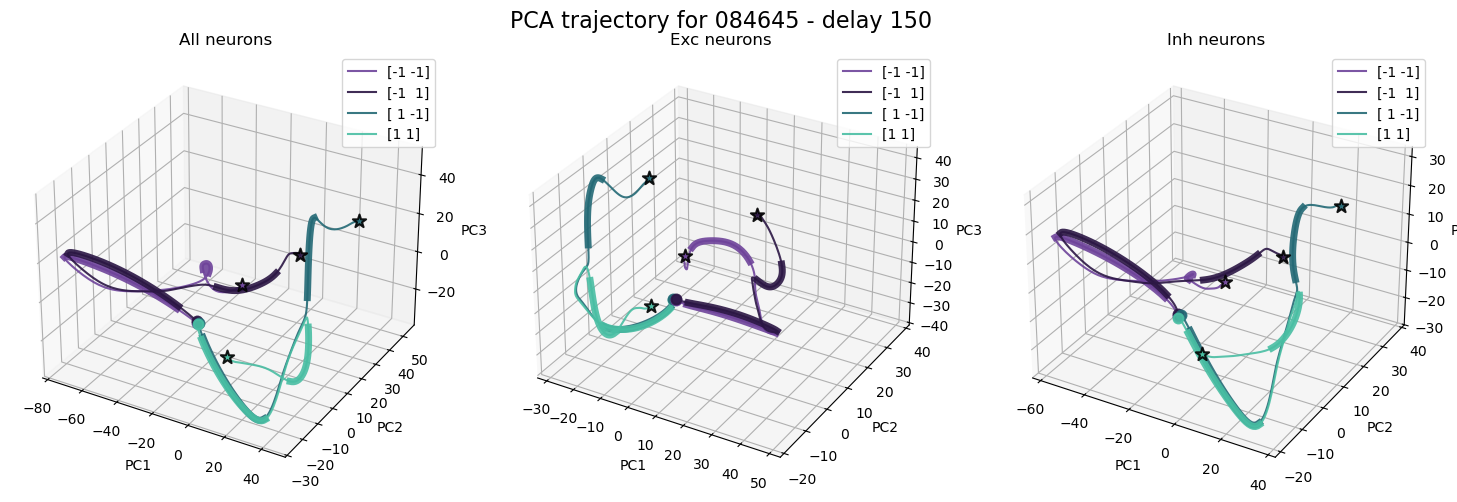

In [14]:
importlib.reload(pu)
# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
_, pca_exc = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150,
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
_, pca_inh = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150,
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()

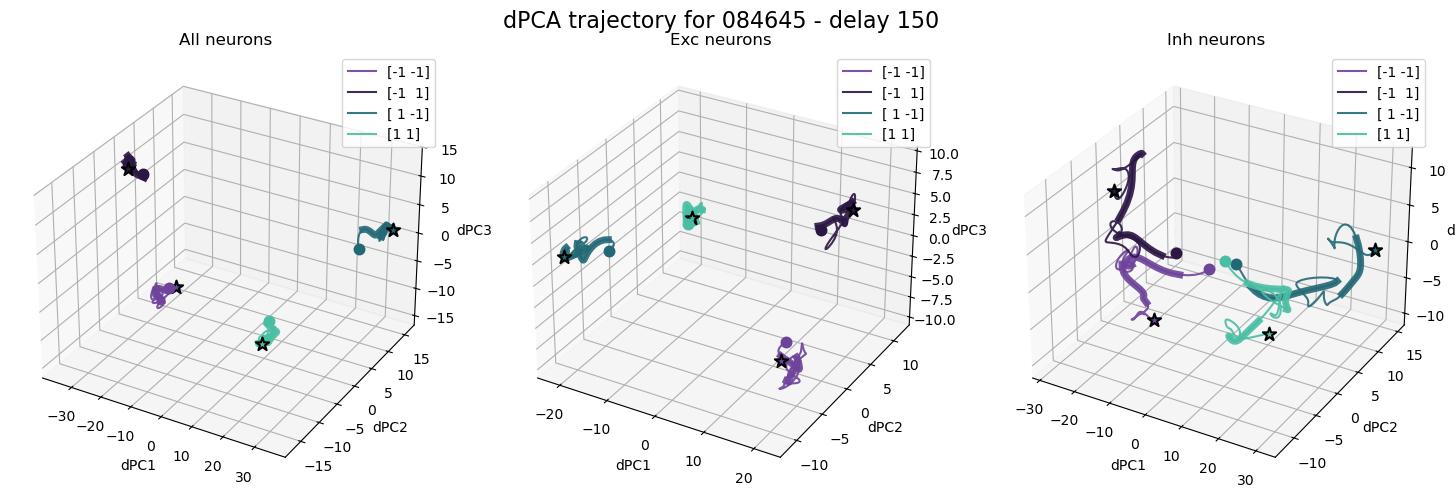

In [37]:
# make 3d plot with 3 subplots
importlib.reload(pu)

%matplotlib inline
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=150, plot_type='s', ds=15,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
_, dpca_obj_exc = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=150, plot_type='s', ds=15,
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
_, dpca_obj_inh = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=150, plot_type='s', ds=15,
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
rates_data.shape

(2055, 200, 1000)

Avg trial perfs: 0.68
PCA explained variance: [0.47529305 0.17795064 0.12515077], total: 0.7783944635162823
PCA explained variance: [0.39118555 0.17243412 0.14457062], total: 0.7081902882257849
PCA explained variance: [0.56013882 0.1831541  0.11652622], total: 0.8598191448839716


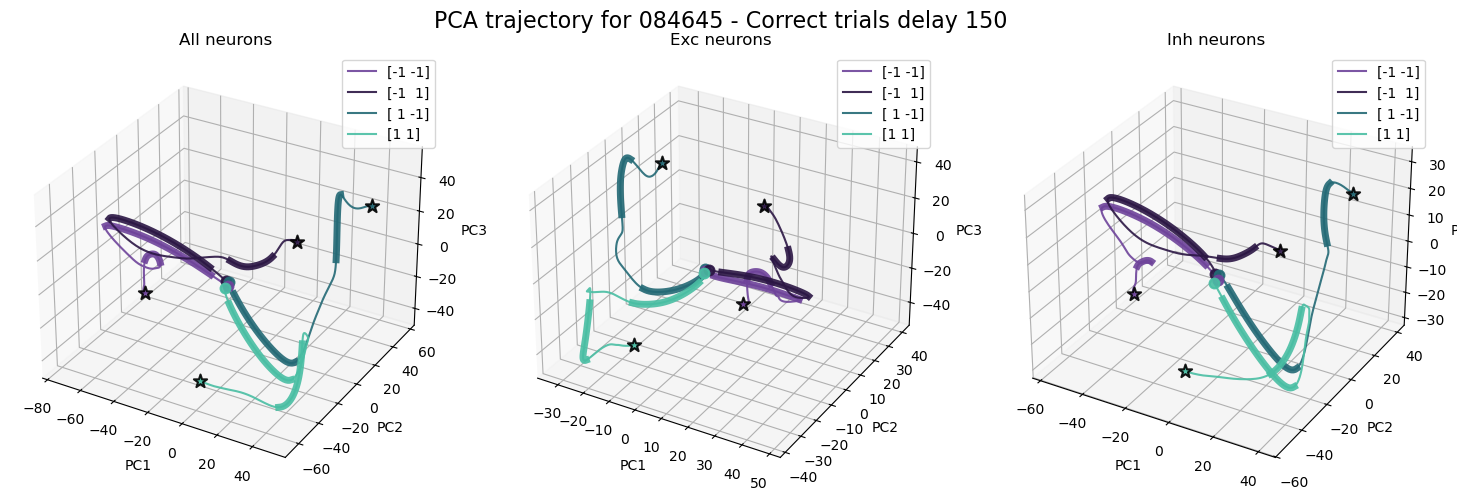

In [15]:
# plot correct trials, PCA
print(f'Avg trial perfs: {np.mean(trial_perfs):.2f}')
importlib.reload(pu)

rates_corr = rates_data[:,:,trial_perfs == 1]
rates_incorr = rates_data[:,:,trial_perfs == 0]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_exc,
                   neuron_ids=exc_ind, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_inh,
                   neuron_ids=inh_ind, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct trials {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()

Avg trial perfs: 0.68


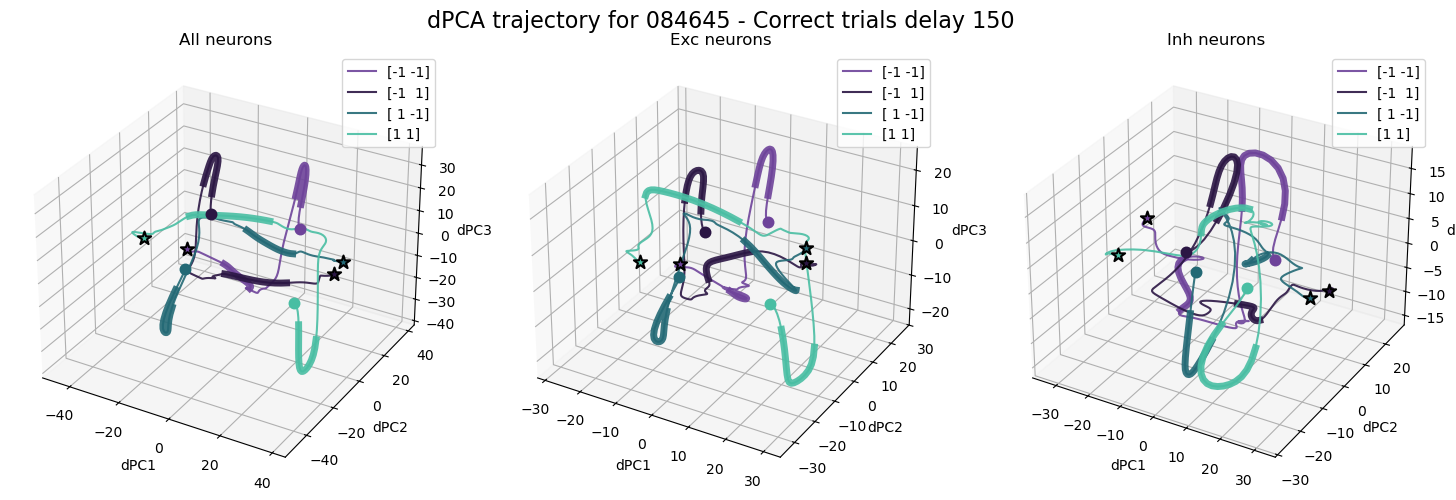

In [43]:
# plot correct trials, dPCA
print(f'Avg trial perfs: {np.mean(trial_perfs):.2f}')
importlib.reload(pu)

rates_corr = rates_data[:,:,trial_perfs == 1]
rates_incorr = rates_data[:,:,trial_perfs == 0]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=150, plot_type='st', ds=15,
                   neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax1, title='All neurons')
_, dpca_obj_exc = pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=150, plot_type='st', ds=15,
                   neuron_ids=exc_ind, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax2, title='Exc neurons')
_, dpca_obj_inh = pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=150, plot_type='st', ds=15,
                   neuron_ids=inh_ind, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - Correct trials {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()

Avg trial perfs: 0.68
PCA explained variance: [0.47529305 0.17795064 0.12515077], total: 0.7783944635162823
PCA explained variance: [0.39118555 0.17243412 0.14457062], total: 0.7081902882257849
PCA explained variance: [0.56013882 0.1831541  0.11652622], total: 0.8598191448839716


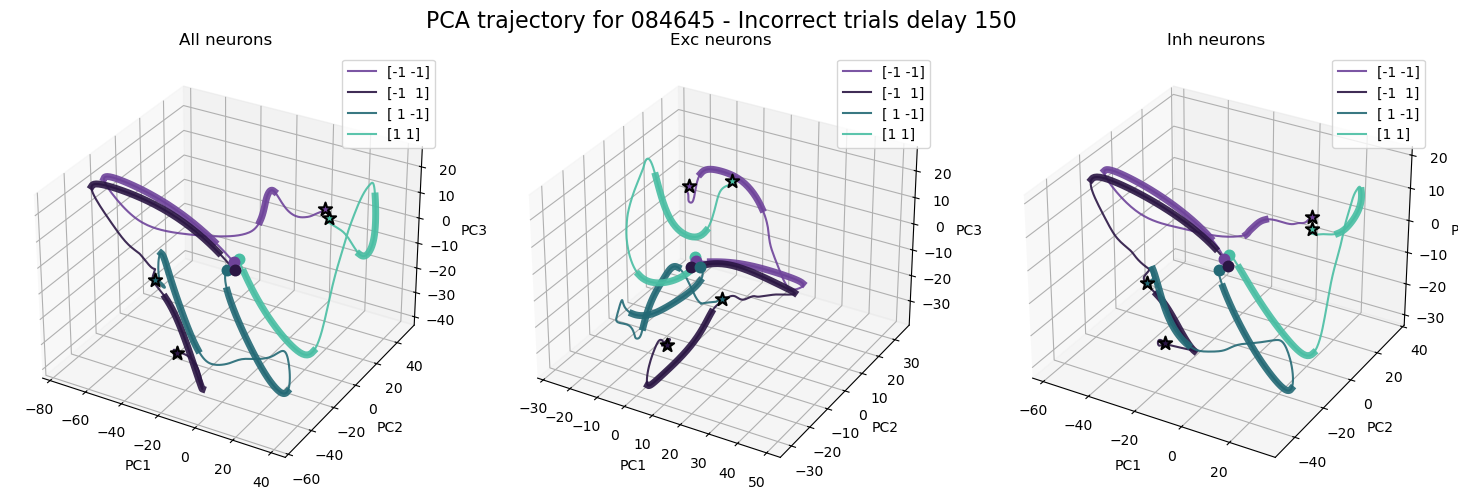

In [8]:
# plot difference between correct and incorrect trials
print(f'Avg trial perfs: {np.mean(trial_perfs):.2f}')
importlib.reload(pu)

rates_corr = rates_data[:,:,trial_perfs == 1]
rates_incorr = rates_data[:,:,trial_perfs == 0]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_exc,
                   neuron_ids=exc_ind, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_inh,
                   neuron_ids=inh_ind, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Incorrect trials {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()

Avg trial perfs: 0.68


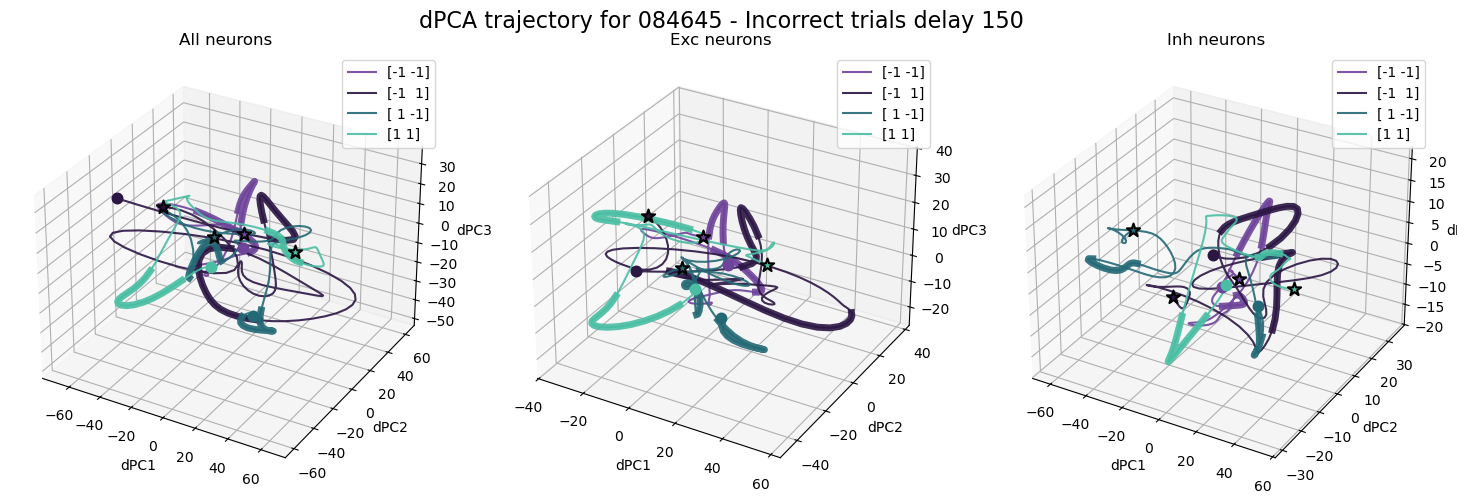

In [44]:
# plot correct trials, dPCA
print(f'Avg trial perfs: {np.mean(trial_perfs):.2f}')
importlib.reload(pu)

rates_corr = rates_data[:,:,trial_perfs == 1]
rates_incorr = rates_data[:,:,trial_perfs == 0]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=150, dpca_obj = dpca_obj_all, plot_type='st',ds=15,
                   neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=150, dpca_obj = dpca_obj_exc, plot_type='st',ds=15,
                   neuron_ids=exc_ind, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=150, dpca_obj = dpca_obj_inh, plot_type='st',ds=15,
                   neuron_ids=inh_ind, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - Incorrect trials {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()

### delay 50

In [5]:
model_name = model_names[1]  # choose first model for now
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=50)
_,_,rates_data = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=50, load_rates=True)
tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase=condn_phrase, condn_num=50)
exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase=condn_phrase, condn_num=50)

PCA explained variance: [0.41261076 0.24070352 0.11948026], total: 0.7727945361445192
PCA explained variance: [0.351945   0.21860435 0.13513818], total: 0.7056875293740779
PCA explained variance: [0.47385299 0.26911281 0.10600478], total: 0.8489705753213532


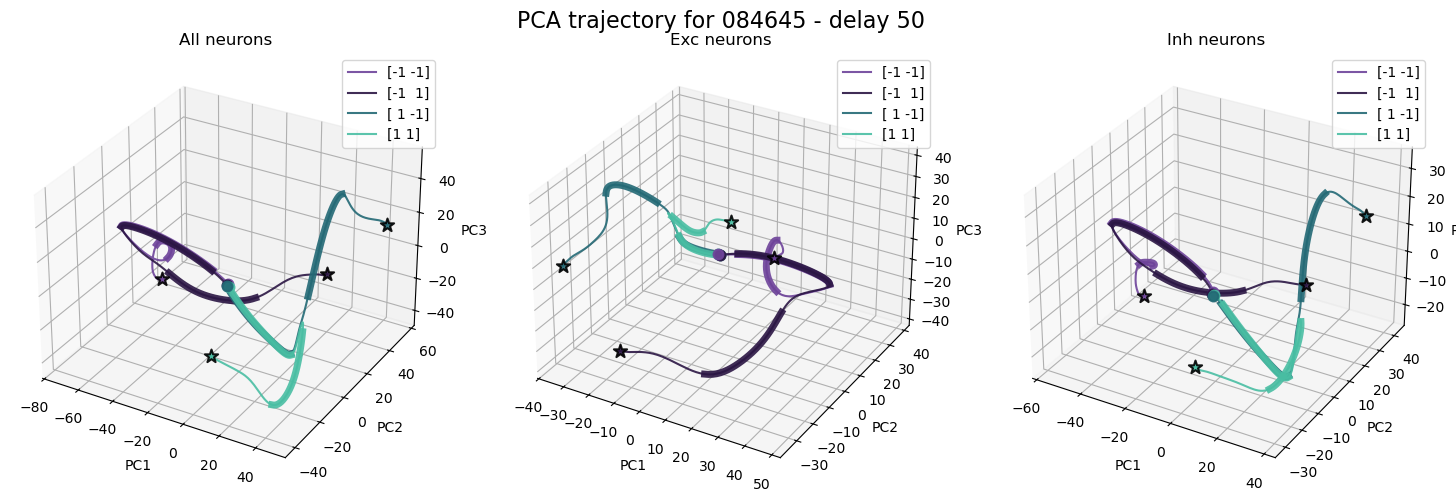

In [6]:
importlib.reload(pu)
# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
_, pca_exc = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50,
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
_, pca_inh = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50,
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {50}', fontsize=16)
plt.tight_layout()
plt.show()

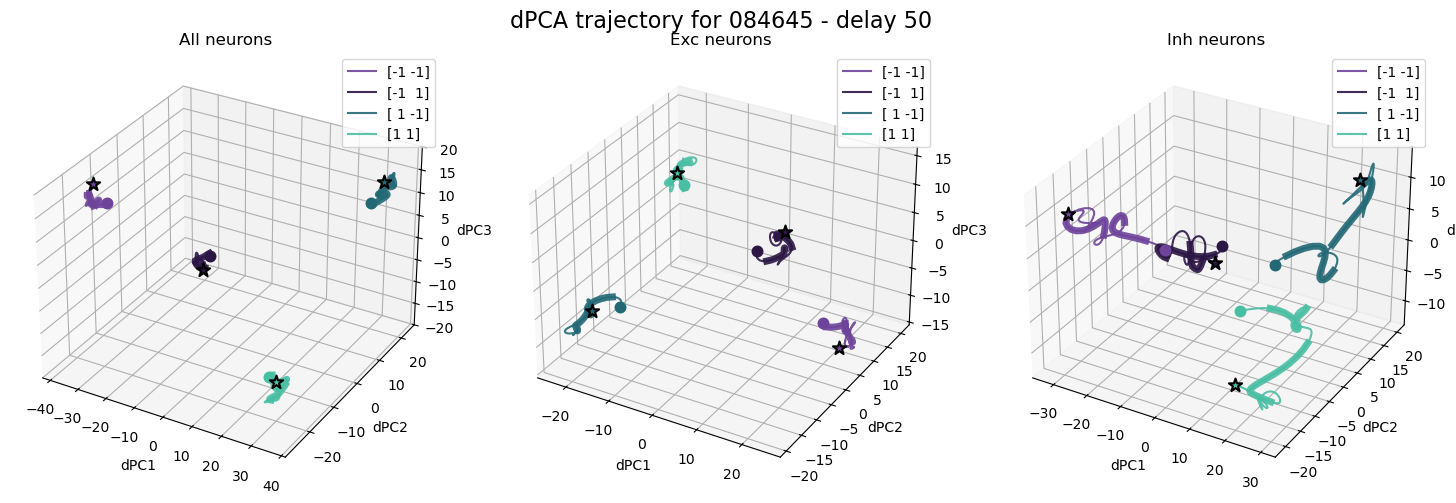

In [18]:
# make 3d plot with 3 subplots
importlib.reload(pu)

%matplotlib inline
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=50, plot_type='s', ds=15,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
_, dpca_obj_exc = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=50, plot_type='s', ds=15,
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
_, dpca_obj_inh = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=50, plot_type='s', ds=15,
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - {condn_phrase} {50}', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
rates_data.shape

(2055, 200, 1000)

Avg trial perfs: 0.86


PCA explained variance: [0.41261076 0.24070352 0.11948026], total: 0.7727945361445192
PCA explained variance: [0.351945   0.21860435 0.13513818], total: 0.7056875293740779
PCA explained variance: [0.47385299 0.26911281 0.10600478], total: 0.8489705753213532


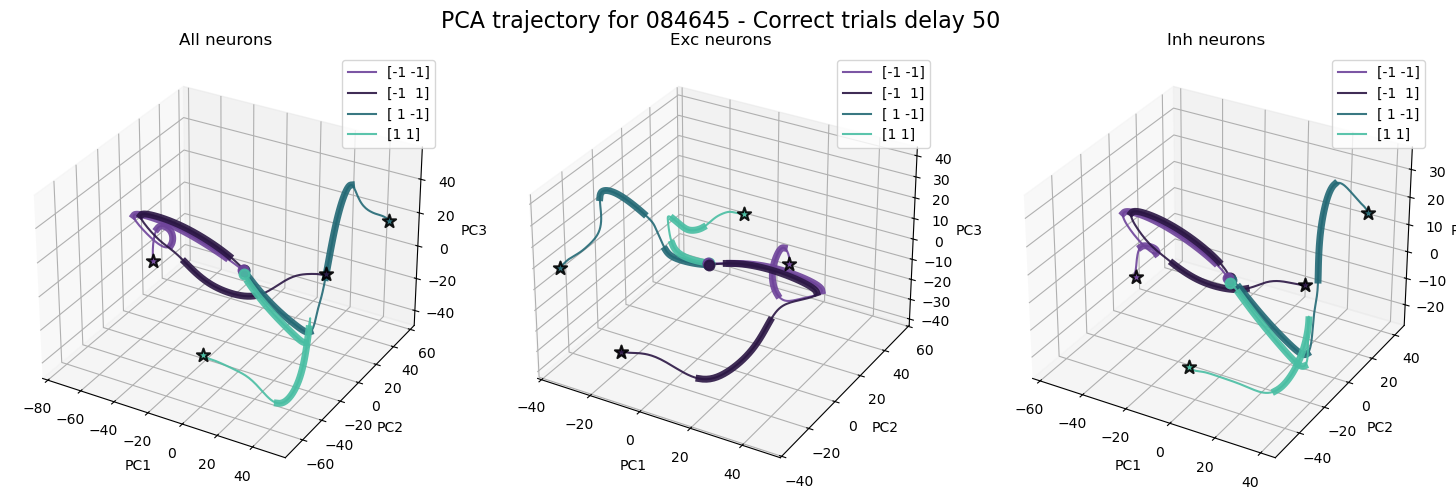

In [7]:
# plot correct trials, PCA
print(f'Avg trial perfs: {np.mean(trial_perfs):.2f}')
importlib.reload(pu)

rates_corr = rates_data[:,:,trial_perfs == 1]
rates_incorr = rates_data[:,:,trial_perfs == 0]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50, pca_obj = pca_exc,
                   neuron_ids=exc_ind, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50, pca_obj = pca_inh,
                   neuron_ids=inh_ind, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct trials {condn_phrase} {50}', fontsize=16)
plt.tight_layout()
plt.show()

Avg trial perfs: 0.86


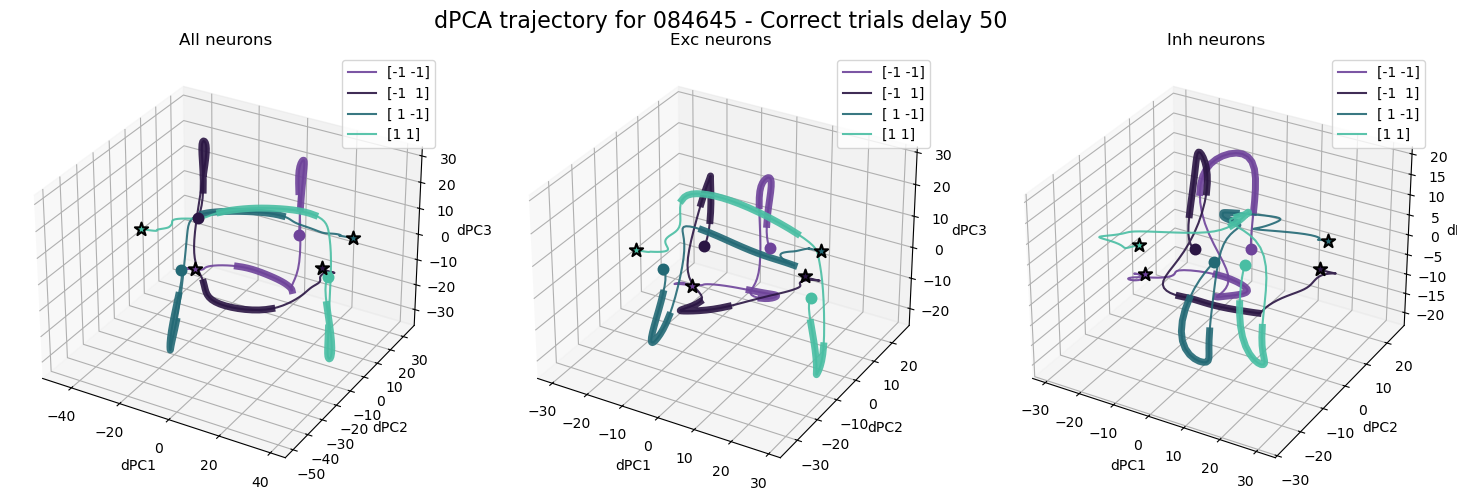

In [20]:
# plot correct trials, dPCA
print(f'Avg trial perfs: {np.mean(trial_perfs):.2f}')
importlib.reload(pu)

rates_corr = rates_data[:,:,trial_perfs == 1]
rates_incorr = rates_data[:,:,trial_perfs == 0]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=50, plot_type='st', ds=15,
                   neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax1, title='All neurons')
_, dpca_obj_exc = pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=50, plot_type='st', ds=15,
                   neuron_ids=exc_ind, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax2, title='Exc neurons')
_, dpca_obj_inh = pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=50, plot_type='st', ds=15,
                   neuron_ids=inh_ind, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - Correct trials {condn_phrase} {50}', fontsize=16)
plt.tight_layout()
plt.show()

Avg trial perfs: 0.86
PCA explained variance: [0.41261076 0.24070352 0.11948026], total: 0.7727945361445192
PCA explained variance: [0.351945   0.21860435 0.13513818], total: 0.7056875293740779
PCA explained variance: [0.47385299 0.26911281 0.10600478], total: 0.8489705753213532


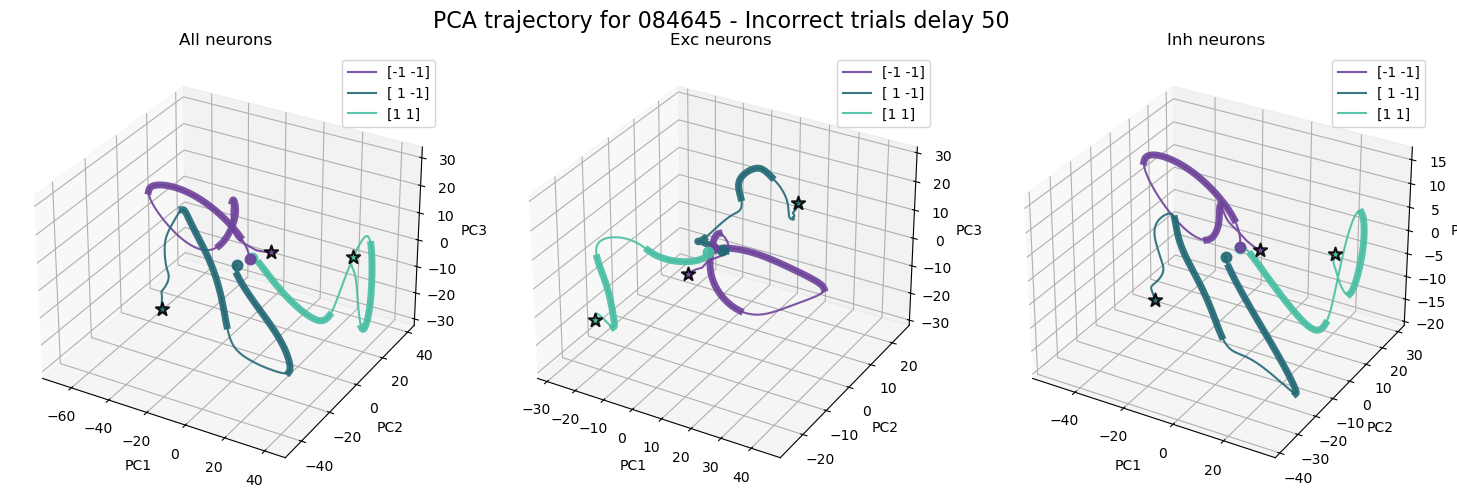

In [8]:
# plot difference between correct and incorrect trials
print(f'Avg trial perfs: {np.mean(trial_perfs):.2f}')
importlib.reload(pu)

rates_corr = rates_data[:,:,trial_perfs == 1]
rates_incorr = rates_data[:,:,trial_perfs == 0]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50, pca_obj = pca_exc,
                   neuron_ids=exc_ind, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50, pca_obj = pca_inh,
                   neuron_ids=inh_ind, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Incorrect trials {condn_phrase} {50}', fontsize=16)
plt.tight_layout()
plt.show()

Avg trial perfs: 0.86


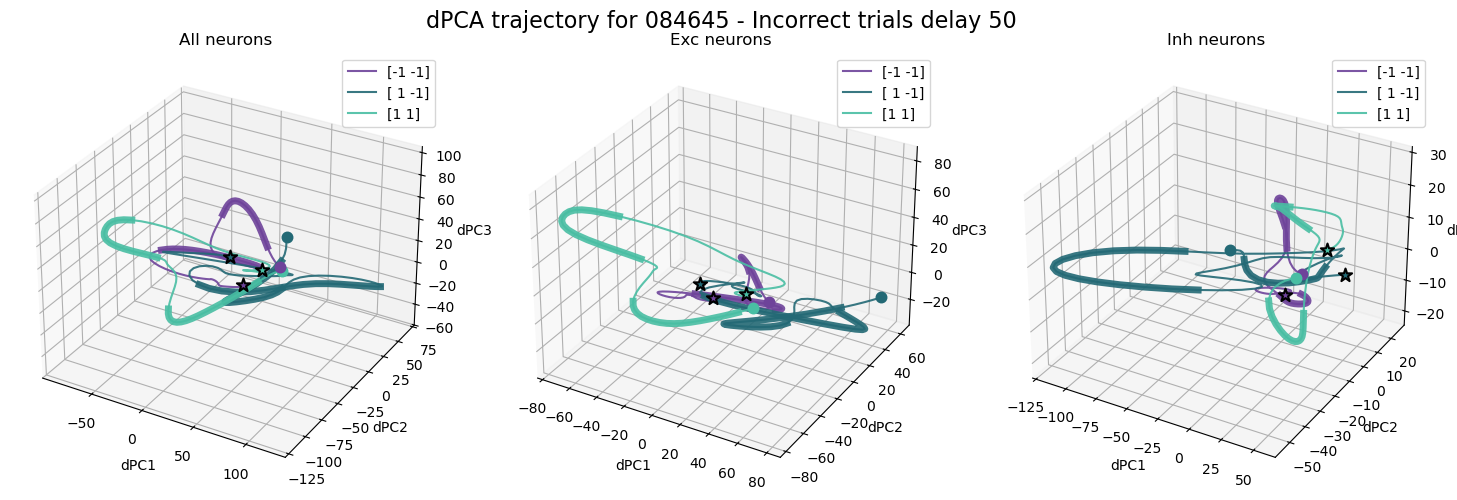

In [22]:
# plot correct trials, dPCA
print(f'Avg trial perfs: {np.mean(trial_perfs):.2f}')
importlib.reload(pu)

rates_corr = rates_data[:,:,trial_perfs == 1]
rates_incorr = rates_data[:,:,trial_perfs == 0]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=50, dpca_obj = dpca_obj_all, plot_type='st',ds=15,
                   neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=50, dpca_obj = dpca_obj_exc, plot_type='st',ds=15,
                   neuron_ids=exc_ind, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase='delay', condn_num=50, dpca_obj = dpca_obj_inh, plot_type='st',ds=15,
                   neuron_ids=inh_ind, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - Incorrect trials {condn_phrase} {50}', fontsize=16)
plt.tight_layout()
plt.show()

### calculate pca pairwise distances?

In [ ]:
_, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')

In [9]:
# load rates data for delay 50 and 150

rates_data_50 = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=50, load_rates=True)[2]
rates_data_150 = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=150, load_rates=True)[2]

PCA explained variance: [0.41261076 0.24070352 0.11948026], total: 0.7727945361445192
PCA explained variance: [0.47529305 0.17795064 0.12515077], total: 0.7783944635162823


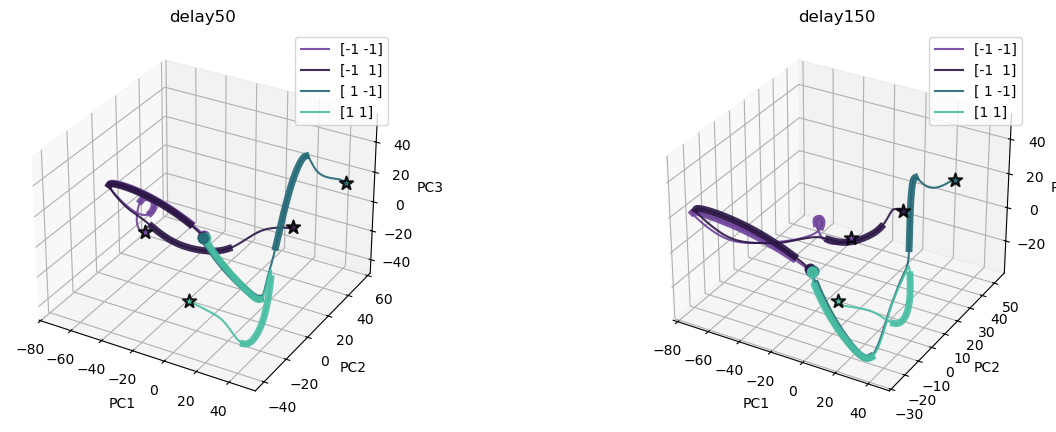

In [51]:
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')
_, pca_50 = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50,
                   neuron_ids=None, rates_data=rates_data_50, cut_off=50, ax=ax1, title='delay50')
_, pca_150 = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, #pca_obj = pca_50,
                   neuron_ids=None, rates_data=rates_data_150, cut_off=50, ax=ax2, title='delay150')

PCA explained variance: [0.41261076 0.24070352 0.11948026], total: 0.7727945361445192
PCA explained variance: [0.41261076 0.24070352 0.11948026], total: 0.7727945361445192


(<Axes3D: title={'center': 'delay150'}, xlabel='PC1', ylabel='PC2', zlabel='PC3'>,
 PCA(n_components=3))

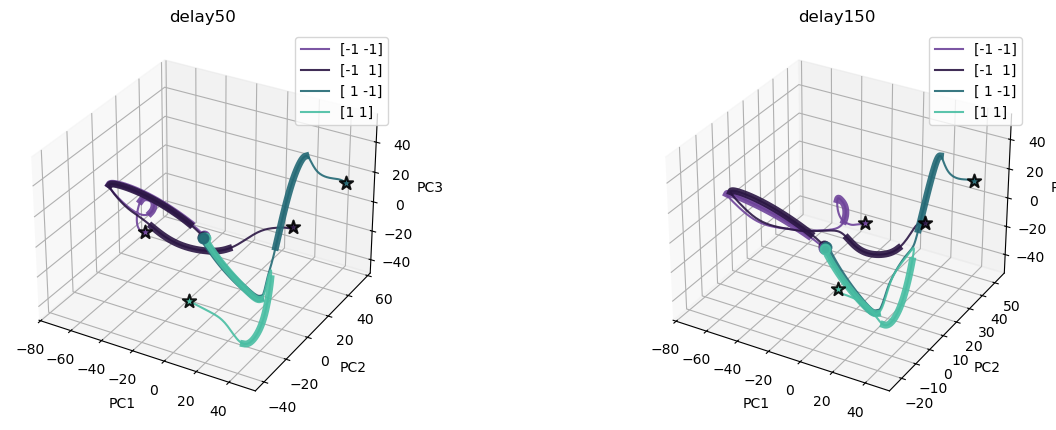

In [ ]:
# using the pca_all obj (from delay=50) for both projections
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50,pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_data_50, cut_off=50, ax=ax1, title='delay50')
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_data_150, cut_off=50, ax=ax2, title='delay150')

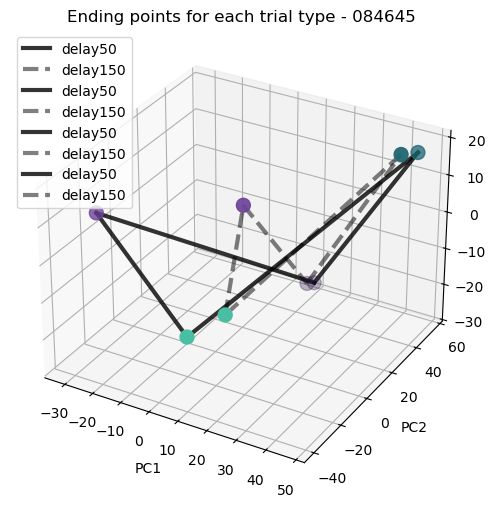

In [13]:
# get mean rates for all trial types
trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
# mean_rates = np.zeros((len(trial_types), rates_data.shape[0], rates_data.shape[1])) # trial_types x time x neurons

endpts_50 = np.zeros((len(trial_types), 3)) # trial_types x 3D coords x neurons
endpts_150 = np.zeros((len(trial_types), 3)) # trial_types x 3D coords x neurons
for i, trial_type in enumerate(trial_types):
    trials_idx = (trial_idxs == i)
    # trials_rate =  # time x neurons x trials
    mean_50 = np.mean(rates_data_50[:, :, trials_idx], axis=2) # avg across trials, time x neurons
    mean_150 = np.mean(rates_data_150[:, :, trials_idx], axis=2) # avg across trials, time x neurons
    traj_50 = pca_all.transform(mean_50)  # fit PCA to mean rates for each trial type
    traj_150 = pca_all.transform(mean_150)  # fit PCA to mean rates for each trial type
    endpts_50[i,:] = traj_50[-1,:]
    endpts_150[i,:] = traj_150[-1,:]
    
# plot ending points for each trial type
stims, colors = ld.get_trialtype_colors()
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
# plot ending points for delay 50 and 150
ax.scatter(endpts_50[:,0], endpts_50[:,1], endpts_50[:,2], c=colors, s=100)
ax.scatter(endpts_150[:,0], endpts_150[:,1], endpts_150[:,2], c=colors, s=100)
# plot lines connecting the ending points
for i in range(len(endpts_50)):
    ax.plot([endpts_50[i,0], endpts_50[(i+1)%len(endpts_50),0]], 
            [endpts_50[i,1], endpts_50[(i+1)%len(endpts_50),1]], 
            [endpts_50[i,2], endpts_50[(i+1)%len(endpts_50),2]], c='k', linewidth=3, linestyle='-', alpha=0.8, label='delay50')
    ax.plot([endpts_150[i,0], endpts_150[(i+1)%len(endpts_150),0]], 
            [endpts_150[i,1], endpts_150[(i+1)%len(endpts_150),1]], 
            [endpts_150[i,2], endpts_150[(i+1)%len(endpts_150),2]], c='k', linewidth=3, linestyle='--', alpha=0.5, label='delay150')
    


# ax.plot(endpts_50[:,0], endpts_50[:,1], endpts_50[:,2], 'o', c = colors, label='delay 50')
# ax.plot(endpts_150[:,0], endpts_150[:,1], endpts_150[:,2], 'o', c=colors, label='delay 150')
plt.title(f'Ending points for each trial type - {model_name[-6:]}')
plt.xlabel('PC1')
plt.ylabel('PC2')
ax1.set_zlabel('PC3')
plt.legend()
plt.show()


In [18]:
mean_50

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

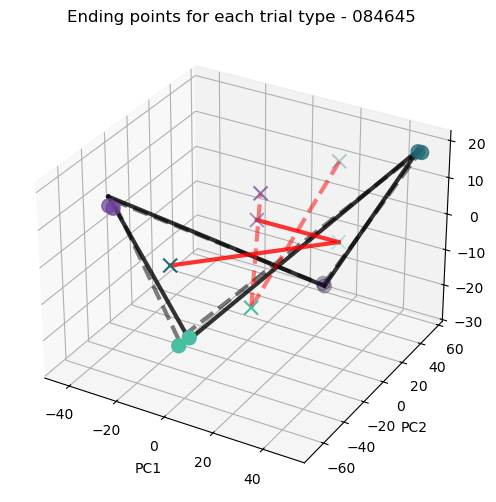

In [22]:
# plot correct and incorrect trials separately

# get mean rates for all trial types
trial_labels, trial_perfs_50 = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=50)
trial_labels, trial_perfs_150 = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=150)
trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)

# mean_rates = np.zeros((len(trial_types), rates_data.shape[0], rates_data.shape[1])) # trial_types x time x neurons

endpts_50_corr = np.zeros((len(trial_types), 3)) # trial_types x 3D coords x neurons
endpts_50_incorr = np.zeros((len(trial_types), 3)) # trial_types x 3D coords x neurons
endpts_150_corr = np.zeros((len(trial_types), 3)) # trial_types x 3D coords x neurons
endpts_150_incorr = np.zeros((len(trial_types), 3)) # trial_types x 3D coords x neurons
for i, trial_type in enumerate(trial_types):
    trials_idx_50 = (trial_idxs == i) & (trial_perfs_50 == 1)  # correct trials
    trials_idx_150 = (trial_idxs == i) & (trial_perfs_150 == 1)  # correct trials
    mean_50 = np.mean(rates_data_50[:, :, trials_idx_50], axis=2) # avg across trials, time x neurons
    mean_150 = np.mean(rates_data_150[:, :, trials_idx_150], axis=2) # avg across trials, time x neurons
    traj_50 = pca_all.transform(mean_50)  # fit PCA to mean rates for each trial type
    traj_150 = pca_all.transform(mean_150)  # fit PCA to mean rates for each trial type
    endpts_50_corr[i,:] = traj_50[-1,:]
    endpts_150_corr[i,:] = traj_150[-1,:]
    
    trials_idx_50 = (trial_idxs == i) & (trial_perfs == 0)  # incorrect trials
    if ~np.any(trials_idx_50):  # if there are no incorrect trials for this trial type, skip
        endpts_50_incorr[i,:] = np.nan
    else:
        mean_50 = np.mean(rates_data_50[:, :, trials_idx_50], axis=2) # avg across trials, time x neurons
        traj_50 = pca_all.transform(mean_50)  # fit PCA to mean rates for each trial type
        endpts_50_incorr[i,:] = traj_50[-1,:]
    trials_idx_150 = (trial_idxs == i) & (trial_perfs == 0)  # incorrect trials
    if ~np.any(trials_idx_150):  # if there are no incorrect trials for this trial type, skip
        endpts_150_incorr[i,:] = np.nan
    else:
        mean_150 = np.mean(rates_data_150[:, :, trials_idx_150], axis=2) # avg across trials, time x neurons
        traj_150 = pca_all.transform(mean_150)  # fit PCA to mean rates for each trial type
        endpts_150_incorr[i,:] = traj_150[-1,:]
    
# plot ending points for each trial type
stims, colors = ld.get_trialtype_colors()
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
# plot ending points for delay 50 and 150
ax.scatter(endpts_50_corr[:,0], endpts_50_corr[:,1], endpts_50[:,2], c=colors, s=100)
ax.scatter(endpts_150_corr[:,0], endpts_150_corr[:,1], endpts_150[:,2], c=colors, s=100)
ax.scatter(endpts_50_incorr[:,0], endpts_50_incorr[:,1], endpts_50_incorr[:,2], c=colors, s=100, marker='x')
ax.scatter(endpts_150_incorr[:,0], endpts_150_incorr[:,1], endpts_150_incorr[:,2], c=colors, s=100, marker='x')
# plot lines connecting the ending points
for i in range(len(endpts_50)):
    ax.plot([endpts_50_corr[i,0], endpts_50_corr[(i+1)%len(endpts_50_corr),0]], 
            [endpts_50_corr[i,1], endpts_50_corr[(i+1)%len(endpts_50_corr),1]], 
            [endpts_50_corr[i,2], endpts_50_corr[(i+1)%len(endpts_50_corr),2]], c='k', linewidth=3, linestyle='-', alpha=0.8, label='delay50')
    ax.plot([endpts_150_corr[i,0], endpts_150_corr[(i+1)%len(endpts_150_corr),0]], 
            [endpts_150_corr[i,1], endpts_150_corr[(i+1)%len(endpts_150_corr),1]], 
            [endpts_150_corr[i,2], endpts_150_corr[(i+1)%len(endpts_150_corr),2]], c='k', linewidth=3, linestyle='--', alpha=0.5, label='delay150')
    
    ax.plot([endpts_50_incorr[i,0], endpts_50_incorr[(i+1)%len(endpts_50_incorr),0]], 
            [endpts_50_incorr[i,1], endpts_50_incorr[(i+1)%len(endpts_50_incorr),1]], 
            [endpts_50_incorr[i,2], endpts_50_incorr[(i+1)%len(endpts_50_incorr),2]], c='r', linewidth=3, linestyle='-', alpha=0.8, label='delay50 incorr')
    ax.plot([endpts_150_incorr[i,0], endpts_150_incorr[(i+1)%len(endpts_150_incorr),0]], 
            [endpts_150_incorr[i,1], endpts_150_incorr[(i+1)%len(endpts_150_incorr),1]], 
            [endpts_150_incorr[i,2], endpts_150_incorr[(i+1)%len(endpts_150_incorr),2]], c='r', linewidth=3, linestyle='--', alpha=0.5, label='delay150 incorr')
    


# ax.plot(endpts_50[:,0], endpts_50[:,1], endpts_50[:,2], 'o', c = colors, label='delay 50')
# ax.plot(endpts_150[:,0], endpts_150[:,1], endpts_150[:,2], 'o', c=colors, label='delay 150')
plt.title(f'Ending points for each trial type - {model_name[-6:]}')
plt.xlabel('PC1')
plt.ylabel('PC2')
ax1.set_zlabel('PC3')
# plt.legend()
plt.show()


In [66]:
# calculate distances between ending points for delay 50 and 150
distances = np.zeros((len(trial_types)))  # trial_types x 2 (delay 50 and 150)
for i in range(len(trial_types)):
    distances[i] = np.linalg.norm(endpts_50[i,:] - endpts_150[i,:])  # distance between ending points for delay 50 and 150

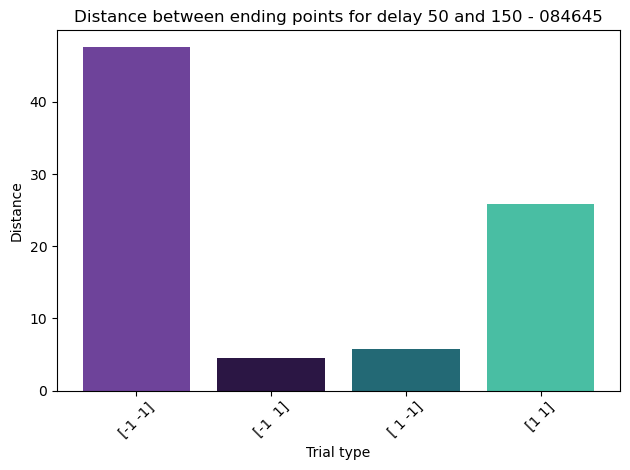

In [67]:
plt.bar(np.arange(len(trial_types)), distances, color=colors)
plt.xticks(np.arange(len(trial_types)), stims, rotation=45)
plt.title(f'Distance between ending points for delay 50 and 150 - {model_name[-6:]}')
plt.xlabel('Trial type')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

## now multiple models

In [5]:
trial_labels, trial_perfs = ld.load_bhv_data(model_names[0], condn_phrase='delay', condn_num=150)
trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)

In [6]:
importlib.reload(pu)
distances_all = np.zeros((len(model_names), len(trial_types)))  # models x trial_types
endpts_50_all = np.zeros((len(model_names), len(trial_types), 3))  # models x trial_types x 3D coords
endpts_150_all = np.zeros((len(model_names), len(trial_types), 3))  # models x trial_types x 3D coords
for i, model_name in enumerate(model_names):
    print(model_name)
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=150)
    trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
    rates_data_50 = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=50, load_rates=True)[2]
    rates_data_150 = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=150, load_rates=True)[2]
    pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=50, plot=0)
    # pca_150 = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, plot=0)
    
    endpts_50 = np.zeros((len(trial_types), 3)) # trial_types x 3D coords x neurons
    endpts_150 = np.zeros((len(trial_types), 3)) # trial_types x 3D coords x neurons
    for j, trial_type in enumerate(trial_types):
        trials_idx = (trial_idxs == j)
        # trials_rate =  # time x neurons x trials
        mean_50 = np.mean(rates_data_50[:, :, trials_idx], axis=2) # avg across trials, time x neurons
        mean_150 = np.mean(rates_data_150[:, :, trials_idx], axis=2) # avg across trials, time x neurons
        traj_50 = pca_all.transform(mean_50)  # fit PCA to mean rates for each trial type
        traj_150 = pca_all.transform(mean_150)  # fit PCA to mean rates for each trial type
        endpts_50[j,:] = traj_50[-1,:]
        endpts_150[j,:] = traj_150[-1,:]
        
    distances_all[i,:] = np.linalg.norm(endpts_50 - endpts_150, axis=1)
    endpts_50_all[i,:,:] = endpts_50
    endpts_150_all[i,:,:] = endpts_150

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_1328

In [ ]:
np.save('results_data/endpts_50_all.npy', endpts_50_all)
np.save('results_data/endpts_150_all.npy', endpts_150_all)
np.save('results_data/distances_all.npy', distances_all)

In [8]:
def plot_endpts(endpts_50, endpts_150, model_name):

    stims, colors = ld.get_trialtype_colors()
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    # plot ending points for delay 50 and 150
    ax.scatter(endpts_50[:,0], endpts_50[:,1], endpts_50[:,2], c=colors, s=100)
    ax.scatter(endpts_150[:,0], endpts_150[:,1], endpts_150[:,2], c=colors, s=100)
    # plot lines connecting the ending points
    for i in range(len(endpts_50)):
        ax.plot([endpts_50[i,0], endpts_50[(i+1)%len(endpts_50),0]], 
                [endpts_50[i,1], endpts_50[(i+1)%len(endpts_50),1]], 
                [endpts_50[i,2], endpts_50[(i+1)%len(endpts_50),2]], c='k', linewidth=3, linestyle='-', alpha=0.8, label='delay50')
        ax.plot([endpts_150[i,0], endpts_150[(i+1)%len(endpts_150),0]], 
                [endpts_150[i,1], endpts_150[(i+1)%len(endpts_150),1]], 
                [endpts_150[i,2], endpts_150[(i+1)%len(endpts_150),2]], c='k', linewidth=3, linestyle='--', alpha=0.5, label='delay150')

    plt.title(f'Ending points for each trial type - {model_name[-6:]}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.legend()
    plt.show()

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648


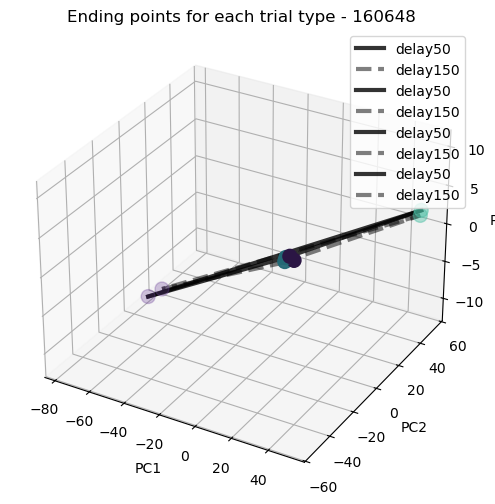

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459


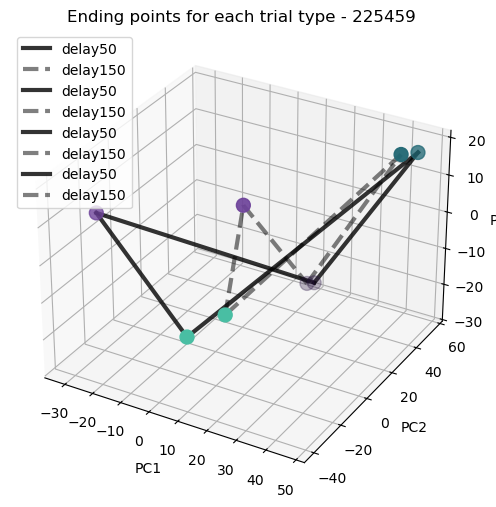

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543


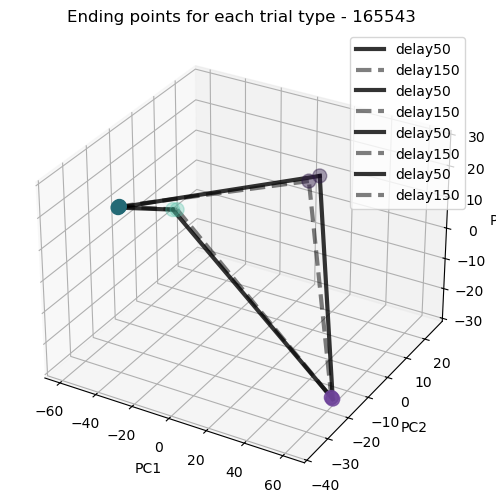

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440


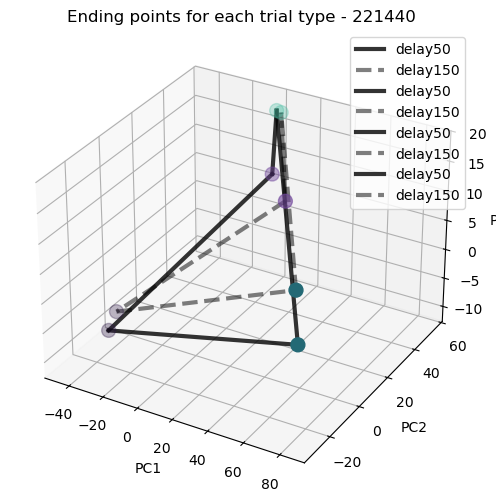

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727


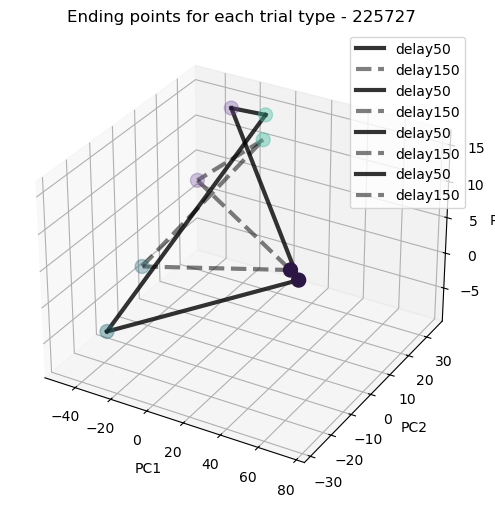

In [9]:
# plot some example model endpoints

for i, model_name in enumerate(model_names[5:10]):
    print(model_name)
    endpts_50 = np.load(f'results_data/endpts_50_all.npy')[i,:,:]
    endpts_150 = np.load(f'results_data/endpts_150_all.npy')[i,:,:]
    plot_endpts(endpts_50, endpts_150, model_name)

In [ ]:
distances_all = np.load('results_data/distances_all.npy')

distances_all.shape

(141, 4)

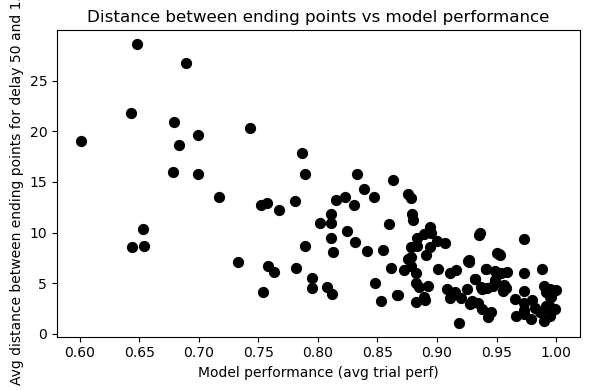

In [12]:
# plot distances between ending points for delay 50 and 150 for all models
distances_mean = np.mean(distances_all, axis=1) # mean for each model

model_perfs = np.zeros((len(model_names)))  # models (delay 150)
for i, model_name in enumerate(model_names):
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=150)
    model_perfs[i] = np.mean(trial_perfs)
    
plt.figure(figsize=(6,4))
plt.scatter(model_perfs, distances_mean, c='k', s=50)
plt.xlabel('Model performance (avg trial perf)')
plt.ylabel('Avg distance between ending points for delay 50 and 150')
plt.title('Distance between ending points vs model performance')
plt.tight_layout()
plt.show()
